# 1_validation_CM.R

In [2]:
wd="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/seurat_obj"
setwd(wd)

library(Seurat)
library(ggplot2)
library(stringr)
library(patchwork)
library(ggpubr)
library(R.utils)

In [3]:
seurat_obj=readRDS(file="Humanxeno_annot.rds")
seurat_obj
seurat_obj=NormalizeData(seurat_obj)
sample_new=rep(NA, times=length(seurat_obj@meta.data$sample))
sample_new[which(seurat_obj@meta.data$sample == "328_1")]="xHTx_1"
sample_new[which(seurat_obj@meta.data$sample == "443_2")]="xHTx_2"
sample_new[which(seurat_obj@meta.data$sample == "535_2")]="Control"
seurat_obj@meta.data$sample_new=sample_new

An object of class Seurat 
36545 features across 20289 samples within 1 assay 
Active assay: RNA (36545 features, 0 variable features)
 1 layer present: counts
 2 dimensional reductions calculated: umap, pca

Normalizing layer: counts



In [4]:
sample=seurat_obj[,which(seurat_obj@meta.data$sample_new =="xHTx_2")]
table(sample@meta.data$cell_type)


                      CM                       EC Endocardial_Lymphatic_EC 
                    1691                      998                        7 
             Fibroblasts          Lymphoids_human           Myeloids_human 
                     381                      646                     2410 
          Neuronal_cells                 Pericyte                      SMC 
                      38                      215                       35 

# 1. Impaired UPR system in pig CMs 

## Impaired UPR system

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


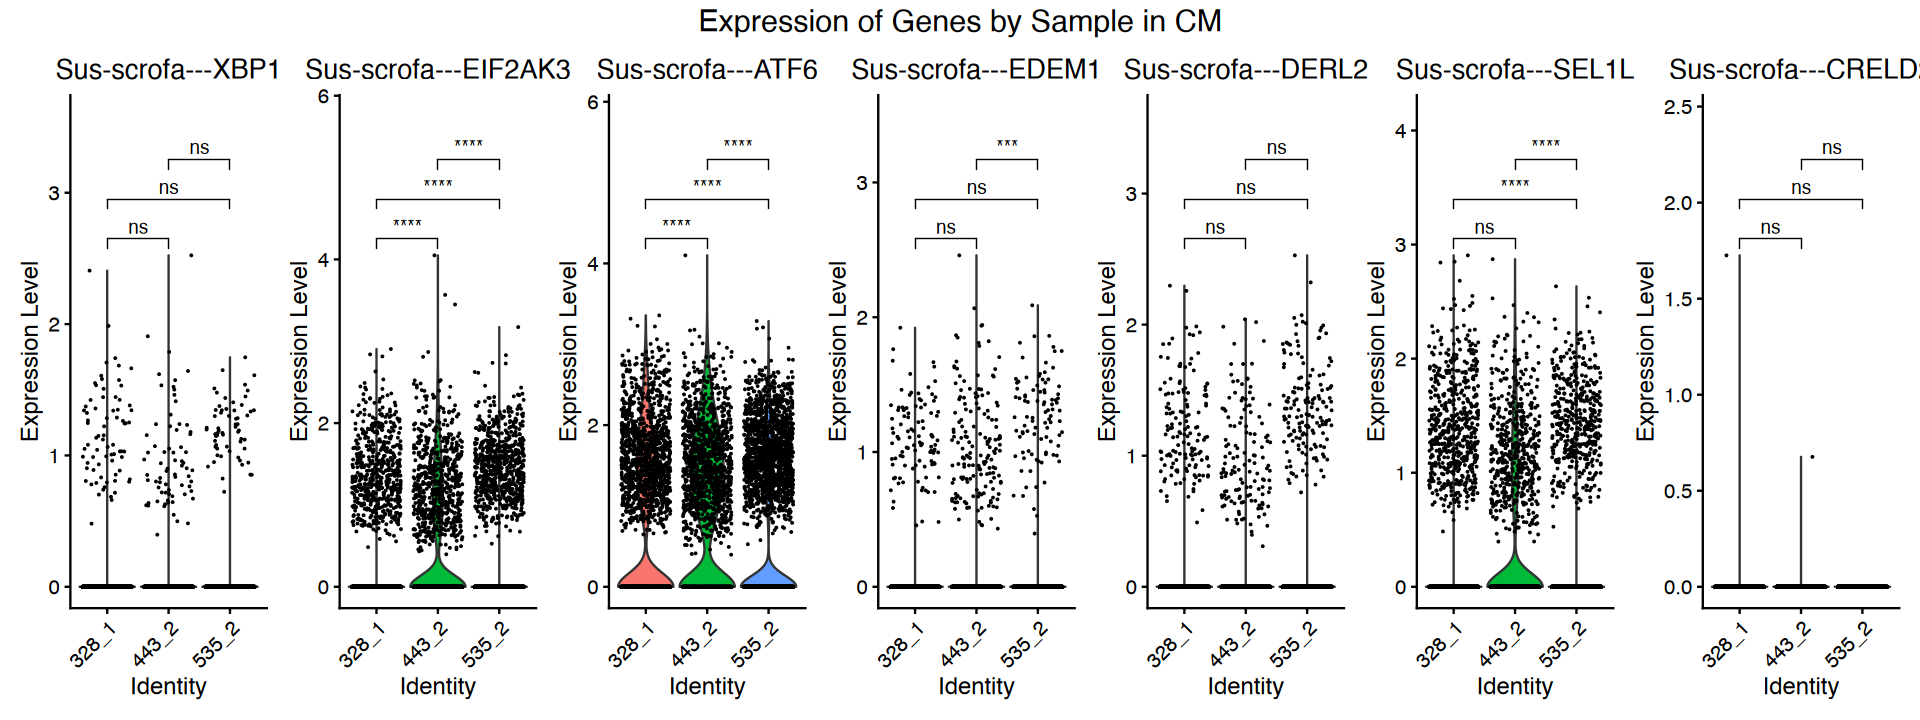

In [35]:
options(repr.plot.width=16, repr.plot.height=6)

features <- c("Sus-scrofa---XBP1", "Sus-scrofa---EIF2AK3", "Sus-scrofa---ATF6", "Sus-scrofa---EDEM1", "Sus-scrofa---DERL2", "Sus-scrofa---SEL1L", "Sus-scrofa---CRELD2")
celltype=c("CM")


my_comparisons <- combn(unique(seurat_obj@meta.data$sample), 2, simplify = FALSE)
for (i in 1:length(celltype)) {
    
    seurat_subset <- subset(seurat_obj, subset = cell_type == celltype[i])
    if (ncol(seurat_subset) == 0) {
      print(paste("Skipping cell type '", celltype[i], "' because it has no cells.", sep=""))
      next 
    }
    plot_list <- list()
    
    for (gene in features) {
        if (gene %in% rownames(seurat_subset)) {
            suppressWarnings({
            p <- VlnPlot(seurat_subset, features = gene, group.by = "sample") +
                 stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif") +
                 theme(legend.position = "none") + 
                 scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
            
            plot_list[[gene]] <- p
            })
        } else {
            print(paste("Skipping gene '", gene, "' for cell type '", celltype[i], "' because it was not found.", sep=""))
        }
    }
    
    if (length(plot_list) == 0) {
        print(paste("No valid plots could be generated for cell type '", celltype[i], "'.", sep=""))
        next
    }

    combined_plot <- wrap_plots(plot_list, ncol = length(features))
    
    final_plot <- combined_plot + plot_annotation(
      title = paste0("Expression of Genes by Sample in ", celltype[i]),
      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))
    )
    
    print(final_plot)
}

## ER chaperones

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


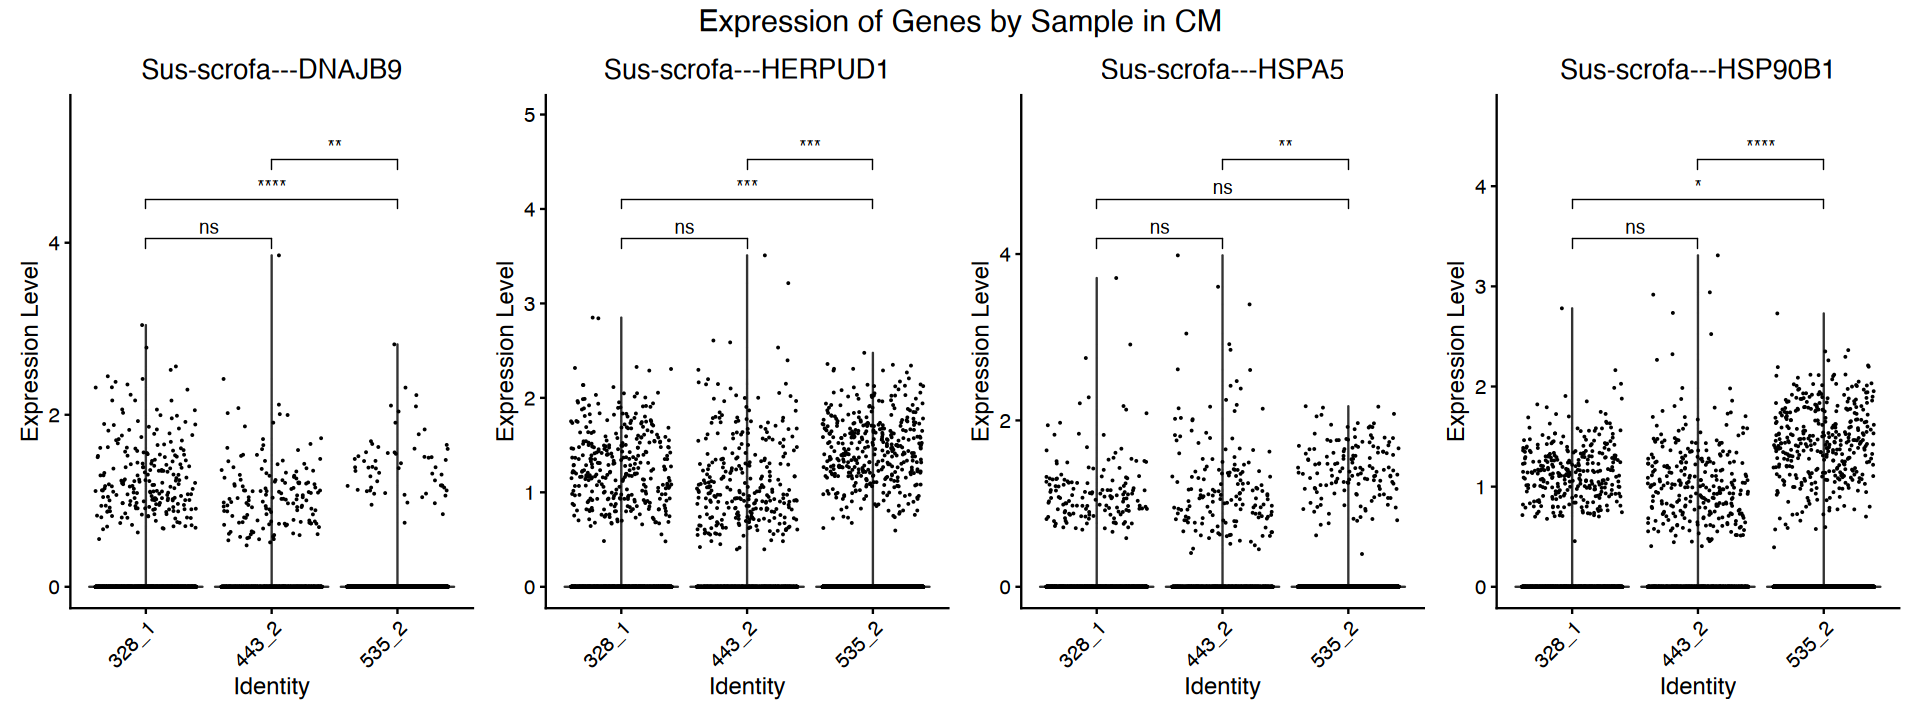

In [36]:
options(repr.plot.width=16, repr.plot.height=6)

features <- c("Sus-scrofa---DNAJB9", "Sus-scrofa---HERPUD1", "Sus-scrofa---HSPA5", "Sus-scrofa---HSP90B1")
celltype=c("CM")


my_comparisons <- combn(unique(seurat_obj@meta.data$sample), 2, simplify = FALSE)
for (i in 1:length(celltype)) {
    
    seurat_subset <- subset(seurat_obj, subset = cell_type == celltype[i])
    if (ncol(seurat_subset) == 0) {
      print(paste("Skipping cell type '", celltype[i], "' because it has no cells.", sep=""))
      next 
    }
    plot_list <- list()
    
    for (gene in features) {
        if (gene %in% rownames(seurat_subset)) {
            suppressWarnings({
            p <- VlnPlot(seurat_subset, features = gene, group.by = "sample") +
                 stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif") +
                 theme(legend.position = "none") + 
                 scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
            
            plot_list[[gene]] <- p
            })
        } else {
            print(paste("Skipping gene '", gene, "' for cell type '", celltype[i], "' because it was not found.", sep=""))
        }
    }
    
    if (length(plot_list) == 0) {
        print(paste("No valid plots could be generated for cell type '", celltype[i], "'.", sep=""))
        next
    }

    combined_plot <- wrap_plots(plot_list, ncol = length(features))
    
    final_plot <- combined_plot + plot_annotation(
      title = paste0("Expression of Genes by Sample in ", celltype[i]),
      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))
    )
    
    print(final_plot)
}

## Activate cellular clearance and degradation pathways

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


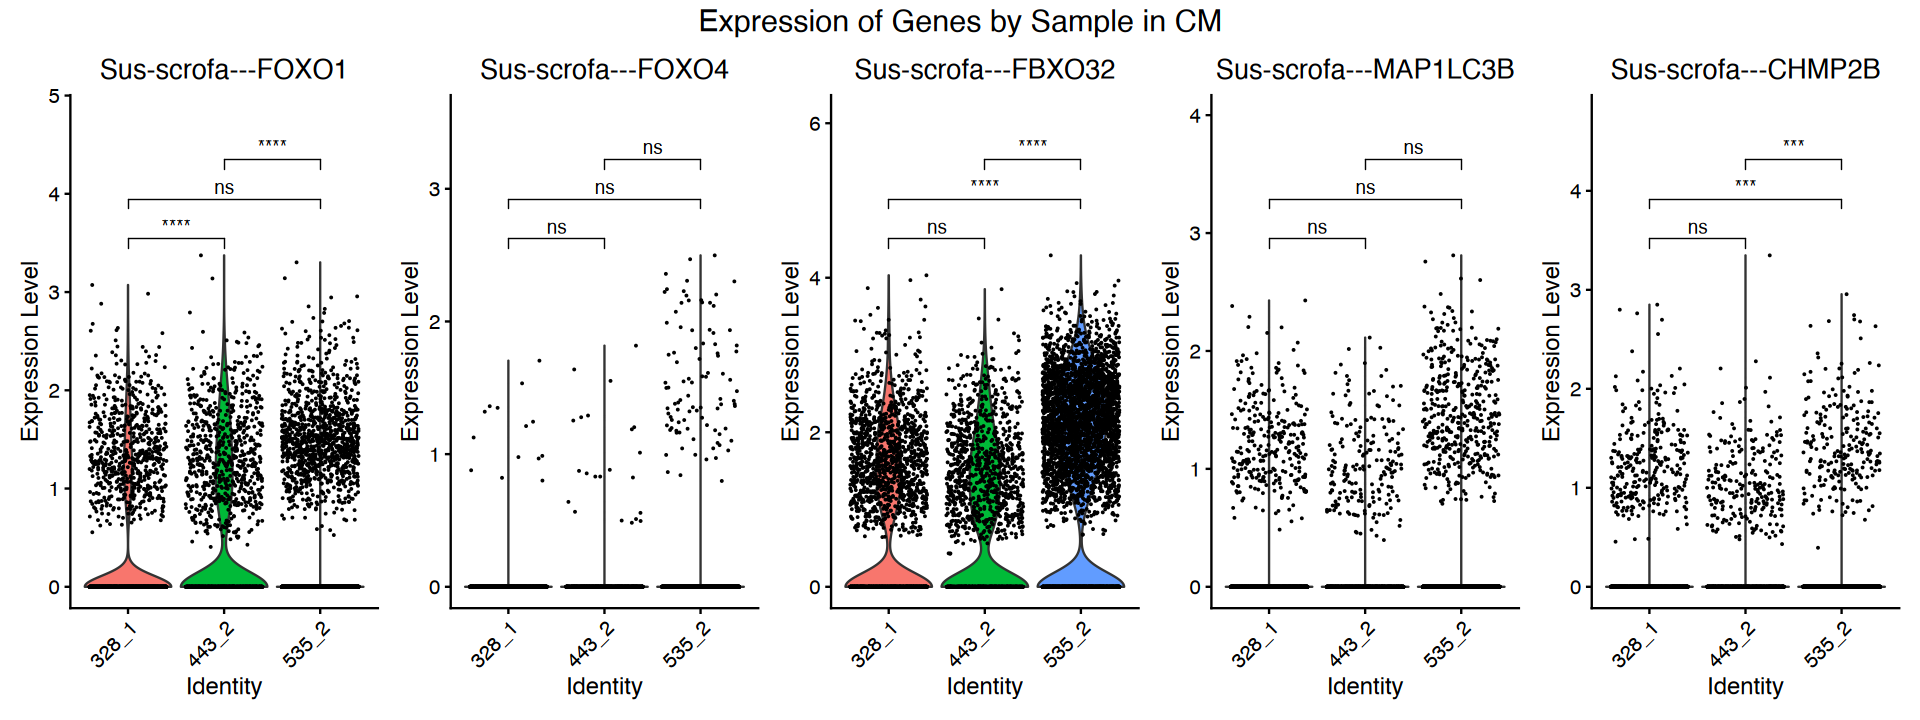

In [37]:
options(repr.plot.width=16, repr.plot.height=6)

features <- c("Sus-scrofa---FOXO1", "Sus-scrofa---FOXO4", "Sus-scrofa---FBXO32", "Sus-scrofa---MAP1LC3B", "Sus-scrofa---CHMP2B")
celltype=c("CM")


my_comparisons <- combn(unique(seurat_obj@meta.data$sample), 2, simplify = FALSE)
for (i in 1:length(celltype)) {
    
    seurat_subset <- subset(seurat_obj, subset = cell_type == celltype[i])
    if (ncol(seurat_subset) == 0) {
      print(paste("Skipping cell type '", celltype[i], "' because it has no cells.", sep=""))
      next 
    }
    plot_list <- list()
    
    for (gene in features) {
        if (gene %in% rownames(seurat_subset)) {
            suppressWarnings({
            p <- VlnPlot(seurat_subset, features = gene, group.by = "sample") +
                 stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif") +
                 theme(legend.position = "none") + 
                 scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
            
            plot_list[[gene]] <- p
            })
        } else {
            print(paste("Skipping gene '", gene, "' for cell type '", celltype[i], "' because it was not found.", sep=""))
        }
    }
    
    if (length(plot_list) == 0) {
        print(paste("No valid plots could be generated for cell type '", celltype[i], "'.", sep=""))
        next
    }

    combined_plot <- wrap_plots(plot_list, ncol = length(features))
    
    final_plot <- combined_plot + plot_annotation(
      title = paste0("Expression of Genes by Sample in ", celltype[i]),
      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))
    )
    
    print(final_plot)
}

# 2. Imparied calcium channel

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


[1] "Skipping gene 'Sus-scrofa---CAMTA' for cell type 'CM' because it was not found."


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


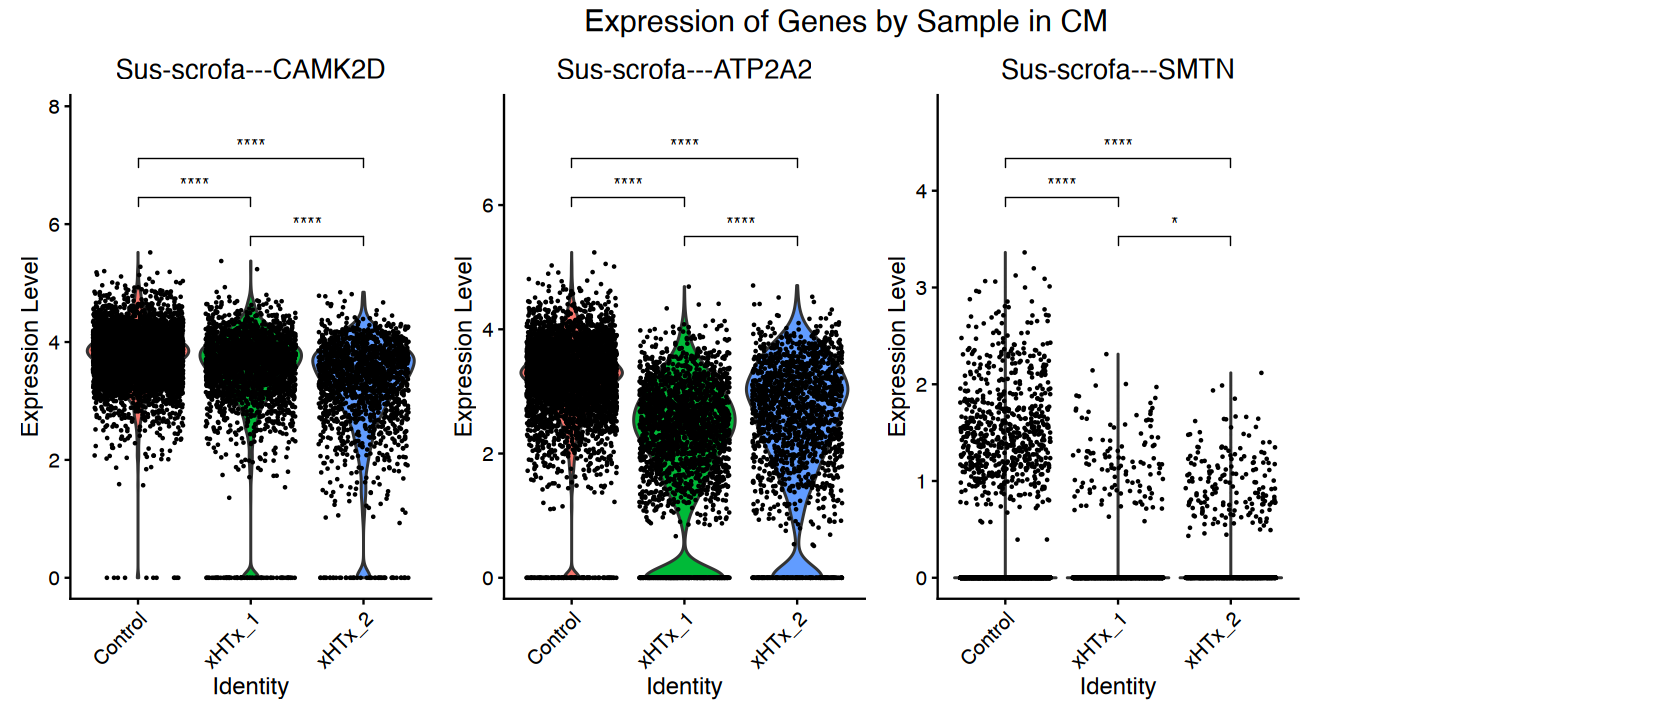

In [5]:
options(repr.plot.width=14, repr.plot.height=6)

features <- c("Sus-scrofa---CAMK2D", "Sus-scrofa---ATP2A2", "Sus-scrofa---CAMTA", "Sus-scrofa---SMTN")
celltype=c("CM")


my_comparisons <- combn(unique(seurat_obj@meta.data$sample_new), 2, simplify = FALSE)
for (i in 1:length(celltype)) {
    
    seurat_subset <- subset(seurat_obj, subset = cell_type == celltype[i])
    if (ncol(seurat_subset) == 0) {
      print(paste("Skipping cell type '", celltype[i], "' because it has no cells.", sep=""))
      next 
    }
    plot_list <- list()
    
    for (gene in features) {
        if (gene %in% rownames(seurat_subset)) {
            suppressWarnings({
            p <- VlnPlot(seurat_subset, features = gene, group.by = "sample_new") +
                 stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif") +
                 theme(legend.position = "none") + 
                 scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
            
            plot_list[[gene]] <- p
            })
        } else {
            print(paste("Skipping gene '", gene, "' for cell type '", celltype[i], "' because it was not found.", sep=""))
        }
    }
    
    if (length(plot_list) == 0) {
        print(paste("No valid plots could be generated for cell type '", celltype[i], "'.", sep=""))
        next
    }

    combined_plot <- wrap_plots(plot_list, ncol = length(features))
    
    final_plot <- combined_plot + plot_annotation(
      title = paste0("Expression of Genes by Sample in ", celltype[i]),
      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))
    )
    
    print(final_plot)
}

In [12]:
# 1. Define the custom order for the X-axis (sample_new)
sample_order <- c("xHTx_1", "xHTx_2", "Control")

# 2. Define the custom color key for the samples
sample_colors <- c(
    "Control" = "#EFE48E",
    "xHTx_1" = "#F0C096",
    "xHTx_2" = "#E09E9E"
)

# 3. Define features and cell type (from your prompt)
features <- c("Sus-scrofa---CAMK2D", "Sus-scrofa---ATP2A2", "Sus-scrofa---CAMTA", "Sus-scrofa---SMTN")
celltype <- c("CM")

# Set global plot options
options(repr.plot.width=14, repr.plot.height=6)

my_comparisons <- combn(sample_order, 2, simplify = FALSE)

for (i in 1:length(celltype)) {
    
    # Subset Seurat object
    seurat_subset <- subset(seurat_obj, subset = cell_type == celltype[i])
    if (ncol(seurat_subset) == 0) {
      print(paste("Skipping cell type '", celltype[i], "' because it has no cells.", sep=""))
      next 
    }

    # CRITICAL STEP: Set the factor levels for the desired X-axis order
    seurat_subset@meta.data$sample_new <- factor(
        seurat_subset@meta.data$sample_new,
        levels = sample_order
    )
    
    plot_list <- list()
    
    for (gene in features) {
        if (gene %in% rownames(seurat_subset)) {
            suppressWarnings({
            p <- VlnPlot(
                 seurat_subset, 
                 features = gene, 
                 group.by = "sample_new",
                 # *** CHANGES HERE: Smaller size and Gray color for the dots ***
                 pt.size = 0,         # Set dot size to a small value
                 cols = "grey20"        # Set the color of the dots to dark gray
            ) +
                 # Apply the custom color scheme for the violin FILL
                 scale_fill_manual(values = sample_colors) +
                 stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif") +
                 theme(legend.position = "none") + 
                 scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
            
            plot_list[[gene]] <- p
            })
        } else {
            print(paste("Skipping gene '", gene, "' for cell type '", celltype[i], "' because it was not found.", sep=""))
        }
    }
    
    if (length(plot_list) == 0) {
        print(paste("No valid plots could be generated for cell type '", celltype[i], "'.", sep=""))
        next
    }

    combined_plot <- wrap_plots(plot_list, ncol = length(features))
    
    final_plot <- combined_plot + plot_annotation(
      title = paste0("Expression of Genes by Sample in ", celltype[i]),
      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))
    )
    pdf(file = "calcium_in_CM.pdf", width = 10, height = 4)
    print(final_plot)
    dev.off()
}

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


[1] "Skipping gene 'Sus-scrofa---CAMTA' for cell type 'CM' because it was not found."


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


In [13]:
################################


# 1. Define the custom order for the X-axis (sample_new)
sample_order <- c("xHTx_1", "xHTx_2", "Control")

# 2. Define the custom color key for the samples
sample_colors <- c(
    "Control" = "#EFE48E",
    "xHTx_1" = "#F0C096",
    "xHTx_2" = "#E09E9E"
)

# 3. Define features and cell type (from your prompt)
features <- c("Sus-scrofa---NPPA", "Sus-scrofa---NPPB", "Sus-scrofa---SMTN",
"Sus-scrofa---CAMTA2")
celltype <- c("CM")

# Set global plot options
options(repr.plot.width=14, repr.plot.height=6)

my_comparisons <- combn(sample_order, 2, simplify = FALSE)

for (i in 1:length(celltype)) {
    
    # Subset Seurat object
    seurat_subset <- subset(seurat_obj, subset = cell_type == celltype[i])
    if (ncol(seurat_subset) == 0) {
      print(paste("Skipping cell type '", celltype[i], "' because it has no cells.", sep=""))
      next 
    }

    # CRITICAL STEP: Set the factor levels for the desired X-axis order
    seurat_subset@meta.data$sample_new <- factor(
        seurat_subset@meta.data$sample_new,
        levels = sample_order
    )
    
    plot_list <- list()
    
    for (gene in features) {
        if (gene %in% rownames(seurat_subset)) {
            suppressWarnings({
            p <- VlnPlot(
                 seurat_subset, 
                 features = gene, 
                 group.by = "sample_new",
                 # *** CHANGES HERE: Smaller size and Gray color for the dots ***
                 pt.size = 0,         # Set dot size to a small value
                 cols = "grey20"        # Set the color of the dots to dark gray
            ) +
                 # Apply the custom color scheme for the violin FILL
                 scale_fill_manual(values = sample_colors) +
                 stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif") +
                 theme(legend.position = "none") + 
                 scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
            
            plot_list[[gene]] <- p
            })
        } else {
            print(paste("Skipping gene '", gene, "' for cell type '", celltype[i], "' because it was not found.", sep=""))
        }
    }
    
    if (length(plot_list) == 0) {
        print(paste("No valid plots could be generated for cell type '", celltype[i], "'.", sep=""))
        next
    }

    combined_plot <- wrap_plots(plot_list, ncol = length(features))
    
    final_plot <- combined_plot + plot_annotation(
      title = paste0("Expression of Genes by Sample in ", celltype[i]),
      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))
    )
    pdf(file = "CM_NPP.pdf", width = 10, height = 4)
    print(final_plot)
    dev.off()
}

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


[1] "Skipping gene 'Sus-scrofa--ISG20' for cell type 'CM' because it was not found."


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


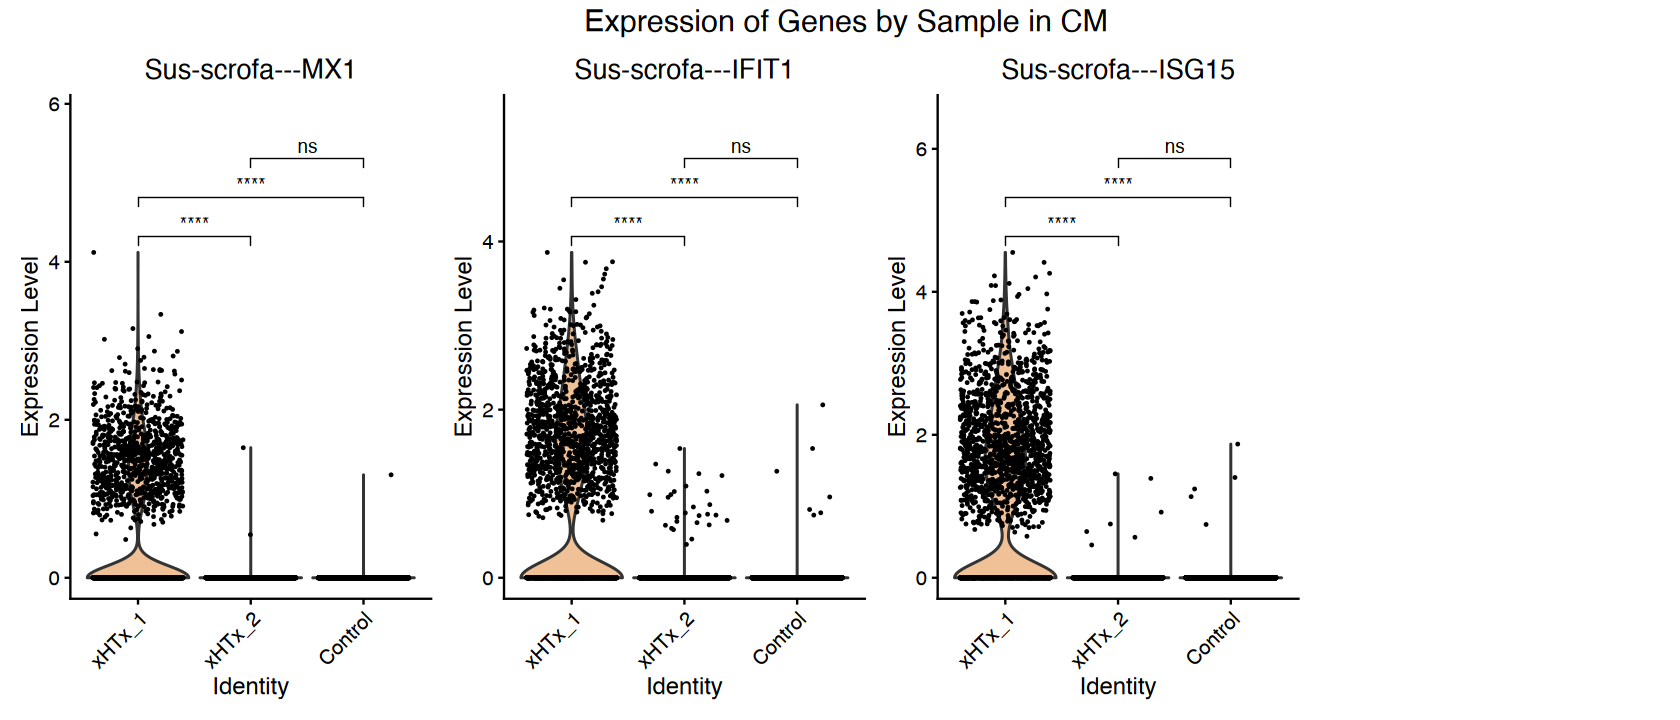

In [23]:
# 1. Define the custom order for the X-axis (sample_new)
sample_order <- c("xHTx_1", "xHTx_2", "Control")

# 2. Define the custom color key for the samples
sample_colors <- c(
    "Control" = "#EFE48E",
    "xHTx_1" = "#F0C096",
    "xHTx_2" = "#E09E9E"
)

# 3. Define features and cell type (from your prompt)
features <- c("Sus-scrofa--ISG20", "Sus-scrofa---MX1", "Sus-scrofa---IFIT1", "Sus-scrofa---ISG15")
celltype <- c("CM")

# Set global plot options
options(repr.plot.width=14, repr.plot.height=6)

my_comparisons <- combn(sample_order, 2, simplify = FALSE)

for (i in 1:length(celltype)) {
    
    # Subset Seurat object
    seurat_subset <- subset(seurat_obj, subset = cell_type == celltype[i])
    if (ncol(seurat_subset) == 0) {
      print(paste("Skipping cell type '", celltype[i], "' because it has no cells.", sep=""))
      next 
    }

    # CRITICAL STEP: Set the factor levels for the desired X-axis order
    seurat_subset@meta.data$sample_new <- factor(
        seurat_subset@meta.data$sample_new,
        levels = sample_order
    )
    
    plot_list <- list()
    
    for (gene in features) {
        if (gene %in% rownames(seurat_subset)) {
            suppressWarnings({
            p <- VlnPlot(
                 seurat_subset, 
                 features = gene, 
                 group.by = "sample_new",
                 # *** CHANGES HERE: Smaller size and Gray color for the dots ***
                 pt.size = 0.1,         # Set dot size to a small value
                 cols = "grey20"        # Set the color of the dots to dark gray
            ) +
                 # Apply the custom color scheme for the violin FILL
                 scale_fill_manual(values = sample_colors) +
                 stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif") +
                 theme(legend.position = "none") + 
                 scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
            
            plot_list[[gene]] <- p
            })
        } else {
            print(paste("Skipping gene '", gene, "' for cell type '", celltype[i], "' because it was not found.", sep=""))
        }
    }
    
    if (length(plot_list) == 0) {
        print(paste("No valid plots could be generated for cell type '", celltype[i], "'.", sep=""))
        next
    }

    combined_plot <- wrap_plots(plot_list, ncol = length(features))
    
    final_plot <- combined_plot + plot_annotation(
      title = paste0("Expression of Genes by Sample in ", celltype[i]),
      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))
    )
    #pdf(file = "ISG_in_EC_new.pdf", width = 10, height = 4)
    print(final_plot)
    #dev.off()
}

# 3. Striking activation of the IL6R–gp130–JAK/STAT axis

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


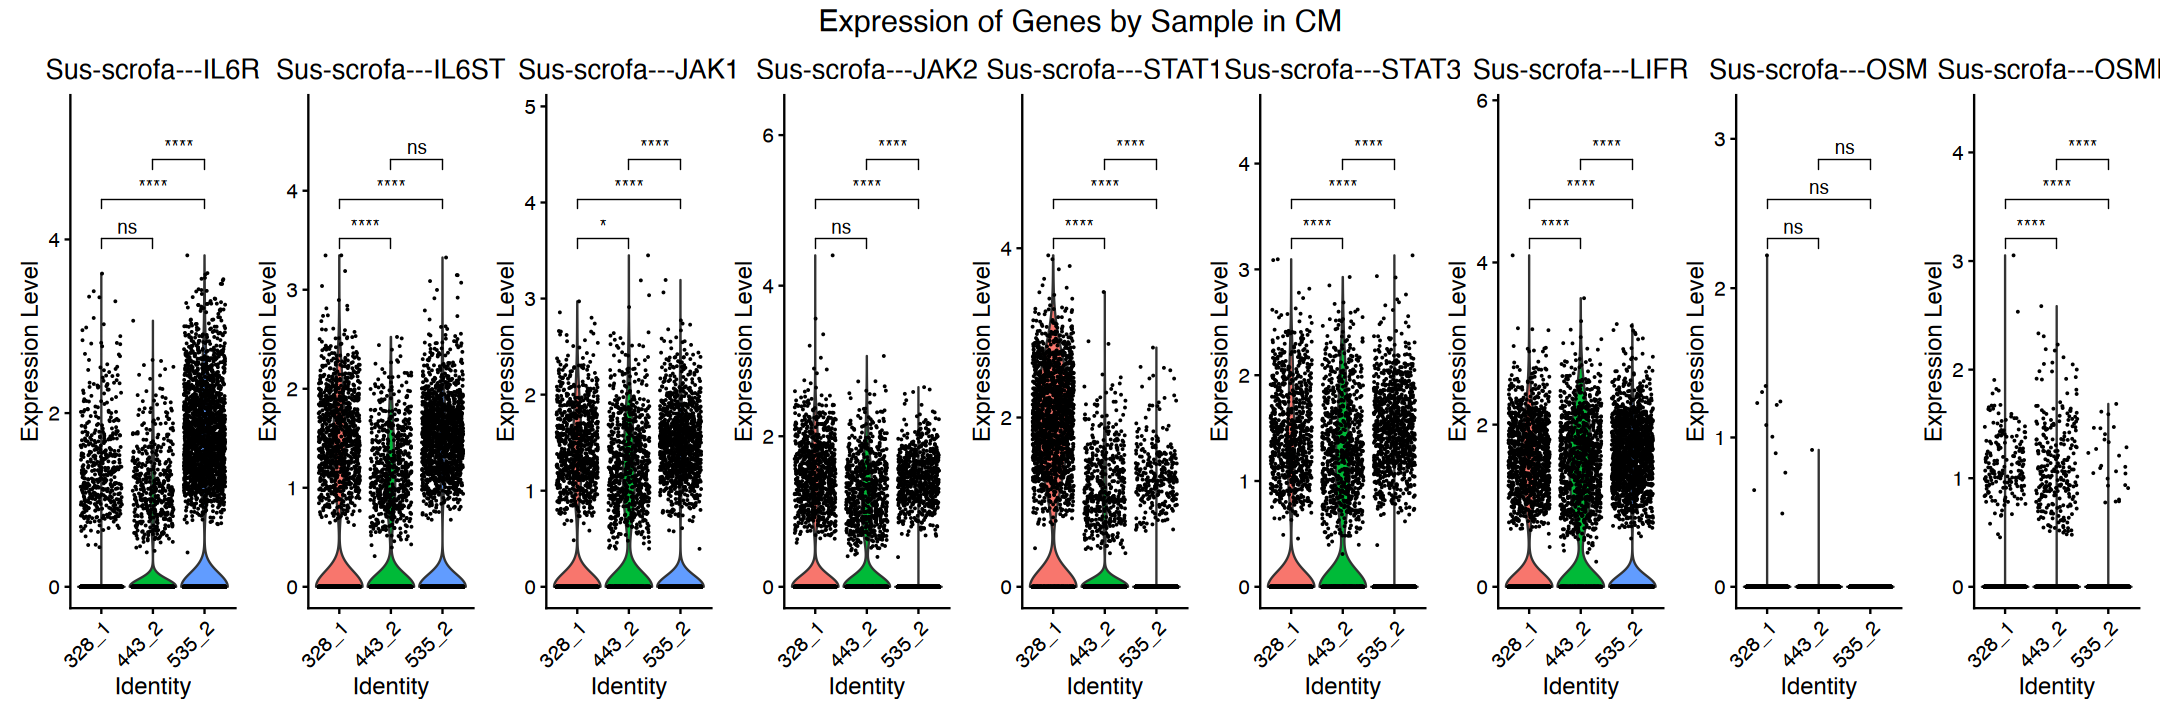

In [41]:
options(repr.plot.width=18, repr.plot.height=6)

features <- c("Sus-scrofa---IL6R", "Sus-scrofa---IL6ST", "Sus-scrofa---JAK1", "Sus-scrofa---JAK2", "Sus-scrofa---STAT1", "Sus-scrofa---STAT3", "Sus-scrofa---LIFR", "Sus-scrofa---OSM", "Sus-scrofa---OSMR")
celltype=c("CM")


my_comparisons <- combn(unique(seurat_obj@meta.data$sample), 2, simplify = FALSE)
for (i in 1:length(celltype)) {
    
    seurat_subset <- subset(seurat_obj, subset = cell_type == celltype[i])
    if (ncol(seurat_subset) == 0) {
      print(paste("Skipping cell type '", celltype[i], "' because it has no cells.", sep=""))
      next 
    }
    plot_list <- list()
    
    for (gene in features) {
        if (gene %in% rownames(seurat_subset)) {
            suppressWarnings({
            p <- VlnPlot(seurat_subset, features = gene, group.by = "sample") +
                 stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif") +
                 theme(legend.position = "none") + 
                 scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
            
            plot_list[[gene]] <- p
            })
        } else {
            print(paste("Skipping gene '", gene, "' for cell type '", celltype[i], "' because it was not found.", sep=""))
        }
    }
    
    if (length(plot_list) == 0) {
        print(paste("No valid plots could be generated for cell type '", celltype[i], "'.", sep=""))
        next
    }

    combined_plot <- wrap_plots(plot_list, ncol = length(features))
    
    final_plot <- combined_plot + plot_annotation(
      title = paste0("Expression of Genes by Sample in ", celltype[i]),
      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))
    )
    
    print(final_plot)
}

# 4. NPPA and NPPB (cardiac hypertrophic genes) 

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


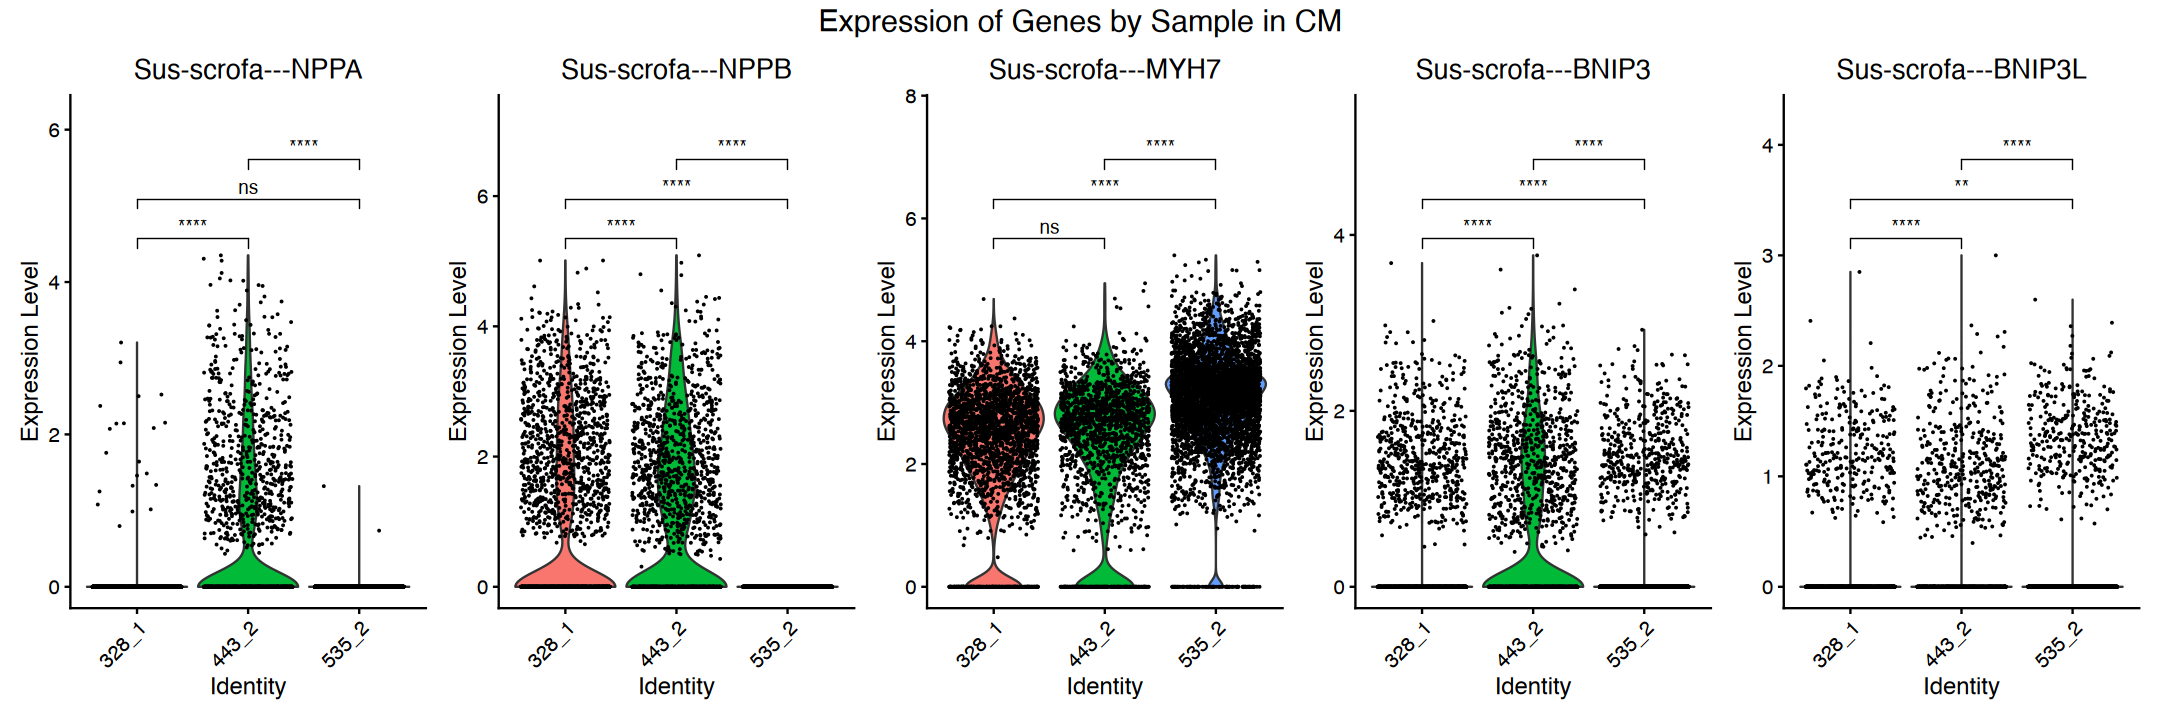

In [47]:
options(repr.plot.width=18, repr.plot.height=6)

features <- c("Sus-scrofa---NPPA", "Sus-scrofa---NPPB", "Sus-scrofa---MYH7", "Sus-scrofa---BNIP3", "Sus-scrofa---BNIP3L")
celltype=c("CM")


my_comparisons <- combn(unique(seurat_obj@meta.data$sample), 2, simplify = FALSE)
for (i in 1:length(celltype)) {
    
    seurat_subset <- subset(seurat_obj, subset = cell_type == celltype[i])
    if (ncol(seurat_subset) == 0) {
      print(paste("Skipping cell type '", celltype[i], "' because it has no cells.", sep=""))
      next 
    }
    plot_list <- list()
    
    for (gene in features) {
        if (gene %in% rownames(seurat_subset)) {
            suppressWarnings({
            p <- VlnPlot(seurat_subset, features = gene, group.by = "sample") +
                 stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif") +
                 theme(legend.position = "none") + 
                 scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
            
            plot_list[[gene]] <- p
            })
        } else {
            print(paste("Skipping gene '", gene, "' for cell type '", celltype[i], "' because it was not found.", sep=""))
        }
    }
    
    if (length(plot_list) == 0) {
        print(paste("No valid plots could be generated for cell type '", celltype[i], "'.", sep=""))
        next
    }

    combined_plot <- wrap_plots(plot_list, ncol = length(features))
    
    final_plot <- combined_plot + plot_annotation(
      title = paste0("Expression of Genes by Sample in ", celltype[i]),
      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))
    )
    
    print(final_plot)
}

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `wilcox.test.default()`:
! not enough 'y' observations”
Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `wilcox.test.default()`:
! not enough 'y' observations”
Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `wilcox.test.default()`:
! not enough 'y' observations”
Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `wilcox.test.default()`:
! not en

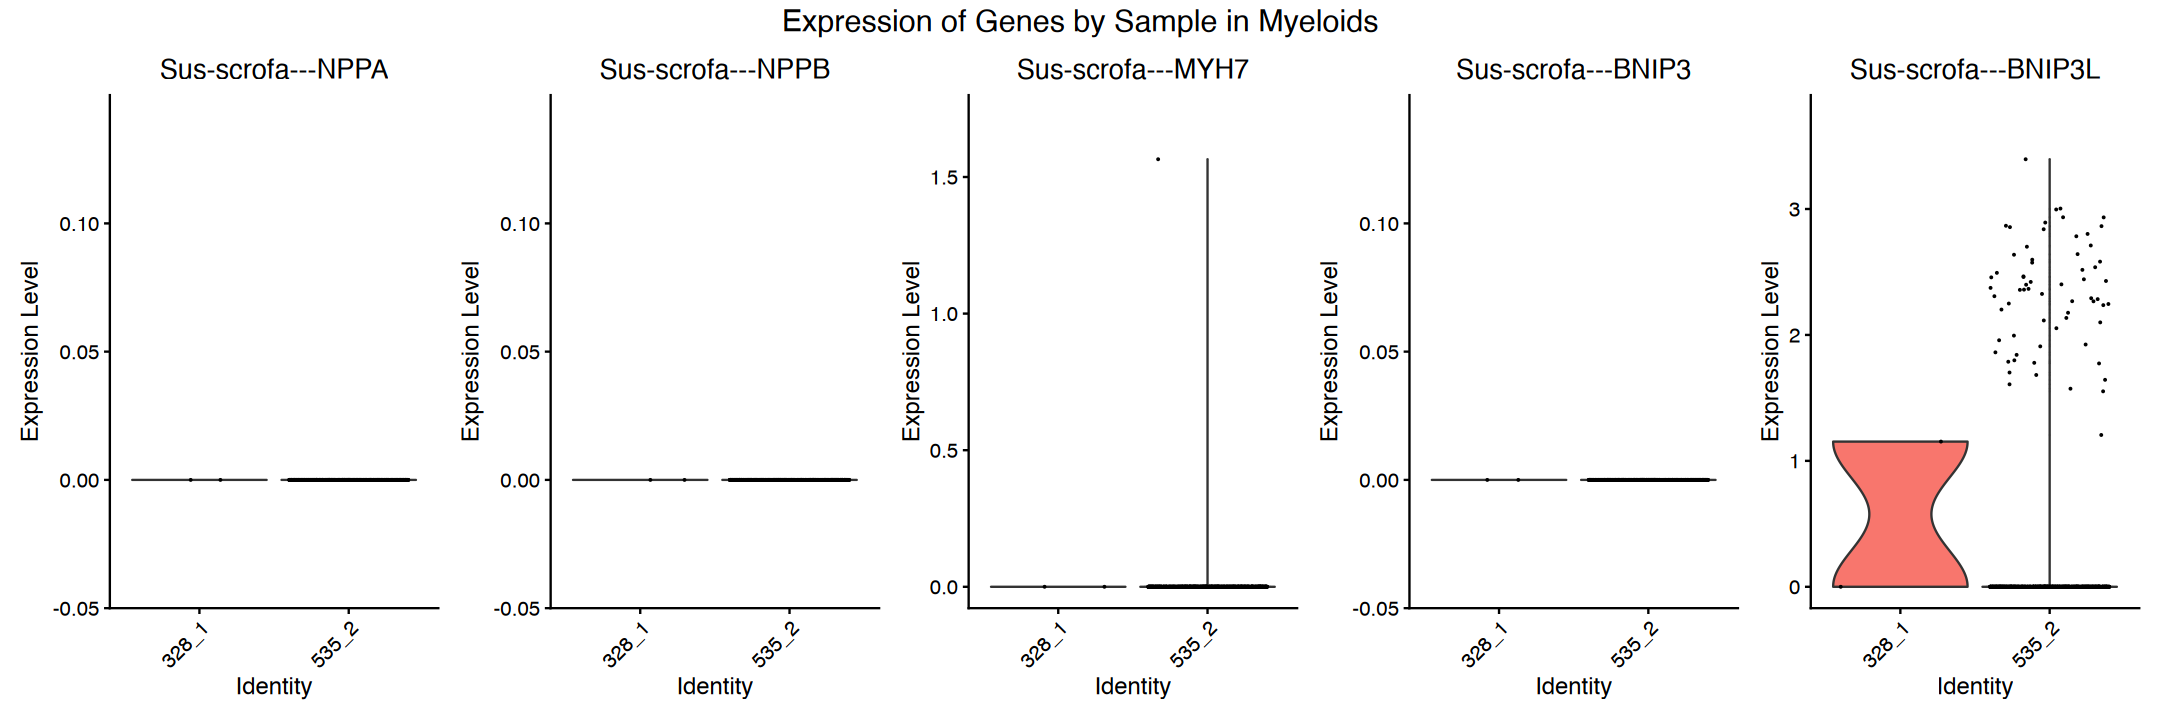

In [49]:
options(repr.plot.width=18, repr.plot.height=6)

features <- c("Sus-scrofa---NPPA", "Sus-scrofa---NPPB", "Sus-scrofa---MYH7", "Sus-scrofa---BNIP3", "Sus-scrofa---BNIP3L")
celltype=c("Myeloids")


my_comparisons <- combn(unique(seurat_obj@meta.data$sample), 2, simplify = FALSE)
for (i in 1:length(celltype)) {
    
    seurat_subset <- subset(seurat_obj, subset = cell_type == celltype[i])
    if (ncol(seurat_subset) == 0) {
      print(paste("Skipping cell type '", celltype[i], "' because it has no cells.", sep=""))
      next 
    }
    plot_list <- list()
    
    for (gene in features) {
        if (gene %in% rownames(seurat_subset)) {
            suppressWarnings({
            p <- VlnPlot(seurat_subset, features = gene, group.by = "sample") +
                 stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif") +
                 theme(legend.position = "none") + 
                 scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
            
            plot_list[[gene]] <- p
            })
        } else {
            print(paste("Skipping gene '", gene, "' for cell type '", celltype[i], "' because it was not found.", sep=""))
        }
    }
    
    if (length(plot_list) == 0) {
        print(paste("No valid plots could be generated for cell type '", celltype[i], "'.", sep=""))
        next
    }

    combined_plot <- wrap_plots(plot_list, ncol = length(features))
    
    final_plot <- combined_plot + plot_annotation(
      title = paste0("Expression of Genes by Sample in ", celltype[i]),
      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))
    )
    
    print(final_plot)
}

# 5. Introduction of ISGs

[1] "Skipping gene 'Sus-scrofa--ISG20' for cell type 'CM' because it was not found."


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


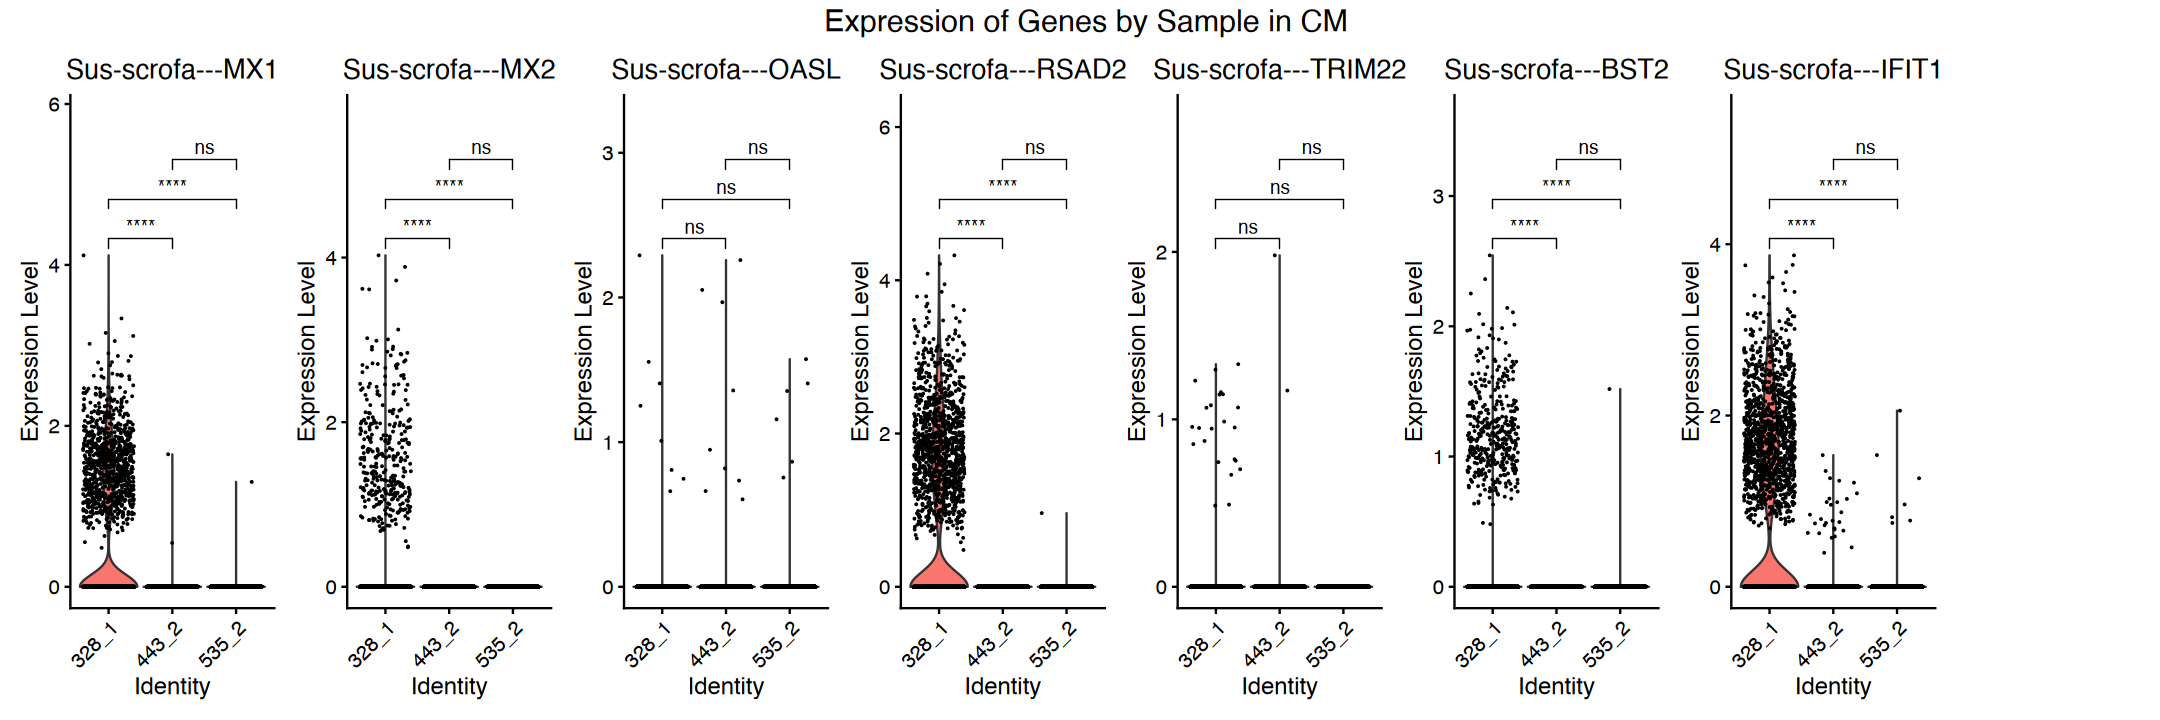

In [52]:
options(repr.plot.width=18, repr.plot.height=6)

features <- c("Sus-scrofa--ISG20", "Sus-scrofa---MX1", "Sus-scrofa---MX2", "Sus-scrofa---OASL", "Sus-scrofa---RSAD2", "Sus-scrofa---TRIM22", "Sus-scrofa---BST2", "Sus-scrofa---IFIT1")
celltype=c("CM")


my_comparisons <- combn(unique(seurat_obj@meta.data$sample), 2, simplify = FALSE)
for (i in 1:length(celltype)) {
    
    seurat_subset <- subset(seurat_obj, subset = cell_type == celltype[i])
    if (ncol(seurat_subset) == 0) {
      print(paste("Skipping cell type '", celltype[i], "' because it has no cells.", sep=""))
      next 
    }
    plot_list <- list()
    
    for (gene in features) {
        if (gene %in% rownames(seurat_subset)) {
            suppressWarnings({
            p <- VlnPlot(seurat_subset, features = gene, group.by = "sample") +
                 stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif") +
                 theme(legend.position = "none") + 
                 scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
            
            plot_list[[gene]] <- p
            })
        } else {
            print(paste("Skipping gene '", gene, "' for cell type '", celltype[i], "' because it was not found.", sep=""))
        }
    }
    
    if (length(plot_list) == 0) {
        print(paste("No valid plots could be generated for cell type '", celltype[i], "'.", sep=""))
        next
    }

    combined_plot <- wrap_plots(plot_list, ncol = length(features))
    
    final_plot <- combined_plot + plot_annotation(
      title = paste0("Expression of Genes by Sample in ", celltype[i]),
      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))
    )
    
    print(final_plot)
}

[1] "Skipping gene 'Sus-scrofa--ISG20' for cell type 'CM' because it was not found."


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


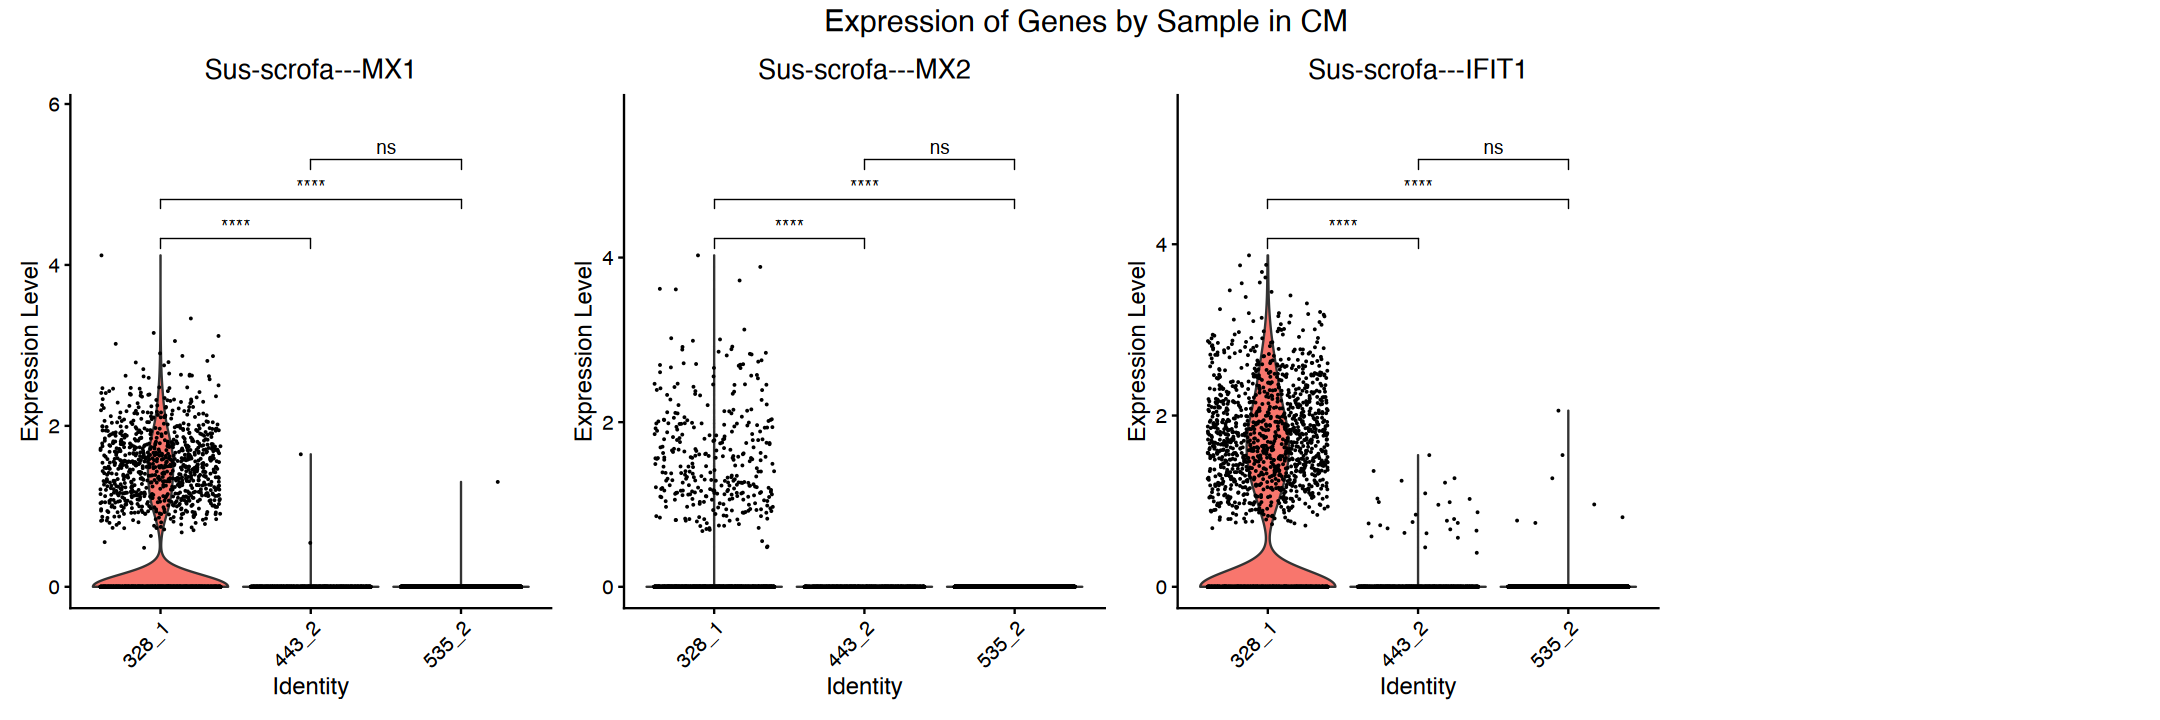

In [5]:
options(repr.plot.width=18, repr.plot.height=6)

features <- c("Sus-scrofa--ISG20", "Sus-scrofa---MX1", "Sus-scrofa---MX2", "Sus-scrofa---IFIT1")
celltype=c("CM")


my_comparisons <- combn(unique(seurat_obj@meta.data$sample), 2, simplify = FALSE)
for (i in 1:length(celltype)) {
    
    seurat_subset <- subset(seurat_obj, subset = cell_type == celltype[i])
    if (ncol(seurat_subset) == 0) {
      print(paste("Skipping cell type '", celltype[i], "' because it has no cells.", sep=""))
      next 
    }
    plot_list <- list()
    
    for (gene in features) {
        if (gene %in% rownames(seurat_subset)) {
            suppressWarnings({
            p <- VlnPlot(seurat_subset, features = gene, group.by = "sample") +
                 stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif") +
                 theme(legend.position = "none") + 
                 scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
            
            plot_list[[gene]] <- p
            })
        } else {
            print(paste("Skipping gene '", gene, "' for cell type '", celltype[i], "' because it was not found.", sep=""))
        }
    }
    
    if (length(plot_list) == 0) {
        print(paste("No valid plots could be generated for cell type '", celltype[i], "'.", sep=""))
        next
    }

    combined_plot <- wrap_plots(plot_list, ncol = length(features))
    
    final_plot <- combined_plot + plot_annotation(
      title = paste0("Expression of Genes by Sample in ", celltype[i]),
      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))
    )
    
    print(final_plot)
}

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


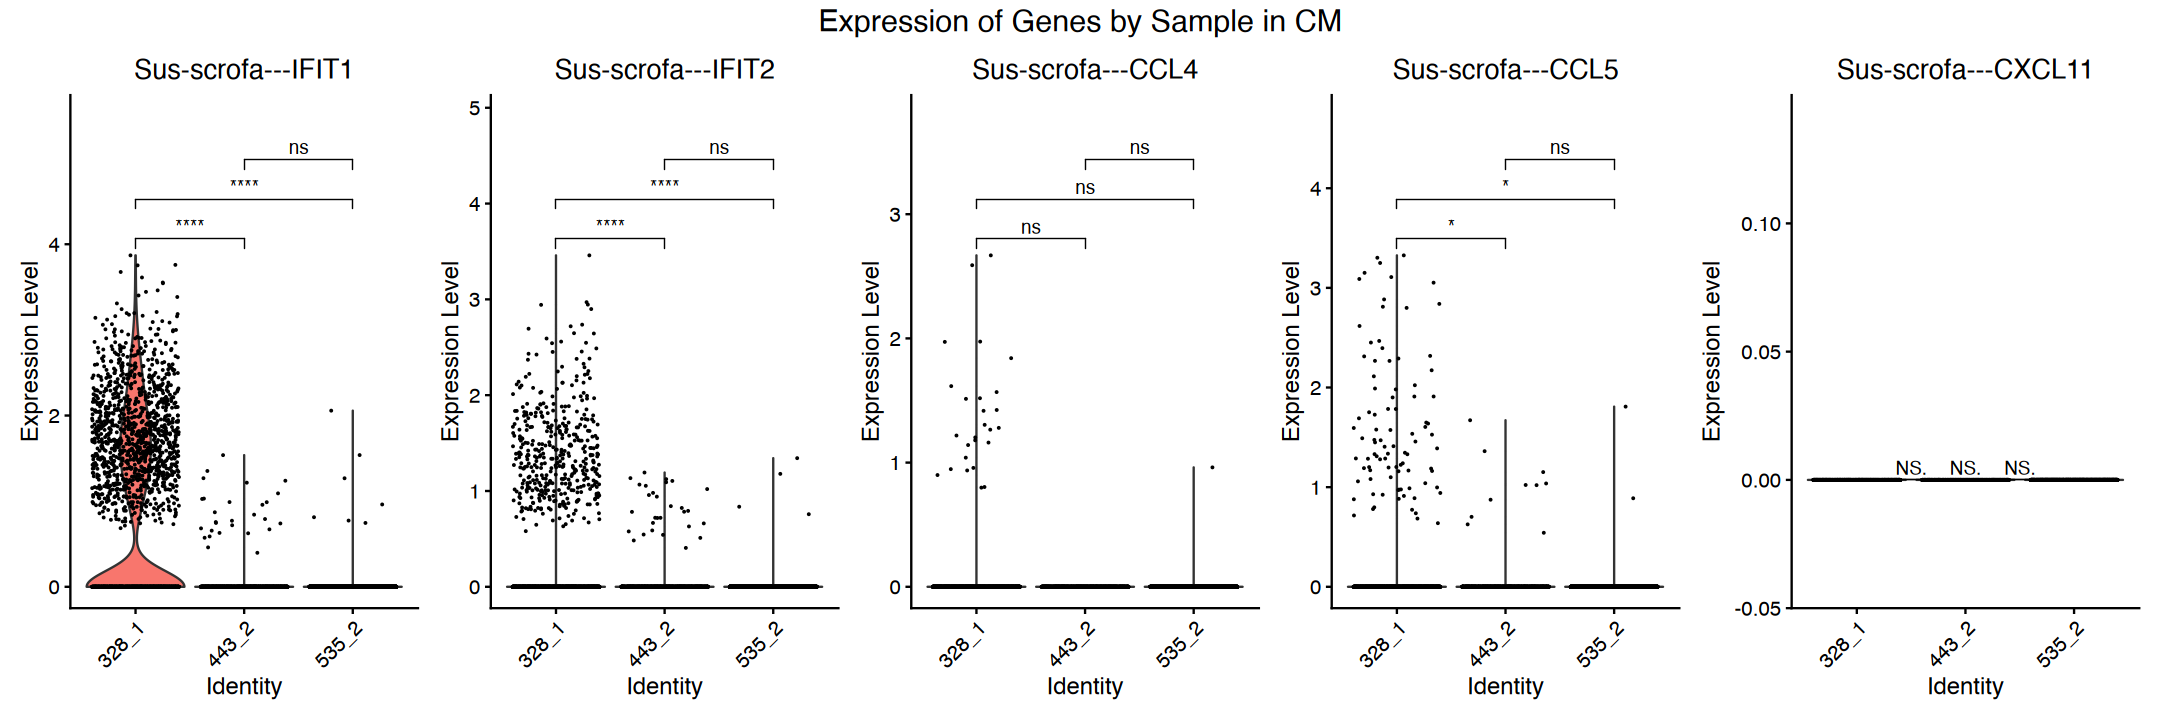

In [51]:
options(repr.plot.width=18, repr.plot.height=6)

features <- c("Sus-scrofa---IFIT1", "Sus-scrofa---IFIT2", "Sus-scrofa---CCL4", "Sus-scrofa---CCL5", "Sus-scrofa---CXCL11")
celltype=c("CM")


my_comparisons <- combn(unique(seurat_obj@meta.data$sample), 2, simplify = FALSE)
for (i in 1:length(celltype)) {
    
    seurat_subset <- subset(seurat_obj, subset = cell_type == celltype[i])
    if (ncol(seurat_subset) == 0) {
      print(paste("Skipping cell type '", celltype[i], "' because it has no cells.", sep=""))
      next 
    }
    plot_list <- list()
    
    for (gene in features) {
        if (gene %in% rownames(seurat_subset)) {
            suppressWarnings({
            p <- VlnPlot(seurat_subset, features = gene, group.by = "sample") +
                 stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif") +
                 theme(legend.position = "none") + 
                 scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
            
            plot_list[[gene]] <- p
            })
        } else {
            print(paste("Skipping gene '", gene, "' for cell type '", celltype[i], "' because it was not found.", sep=""))
        }
    }
    
    if (length(plot_list) == 0) {
        print(paste("No valid plots could be generated for cell type '", celltype[i], "'.", sep=""))
        next
    }

    combined_plot <- wrap_plots(plot_list, ncol = length(features))
    
    final_plot <- combined_plot + plot_annotation(
      title = paste0("Expression of Genes by Sample in ", celltype[i]),
      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))
    )
    
    print(final_plot)
}